In [13]:
import numpy as np

import multi_aster_spindle as mas
%matplotlib widget

import matplotlib.pyplot as plt
import argparse
import os

ceph = '/mnt/home/ealca/ceph/'
# home = '/mnt/home/ealca/'
ceph = '/Users/emrealca/ceph/'

exp_dir = f'{ceph}multi_aster/dt-L/2_aster_test_pushing_and_pulling_10000_tubulin_0.001_temp/'

In [14]:
spindle = mas.retrieve_experiement(experiment_dir=exp_dir, save_trajectory=True, max_states=2000)

543448


Output()

cost vs time plot saved to /Users/emrealca/ceph/multi_aster/dt-L/2_aster_test_pushing_and_pulling_10000_tubulin_0.001_temp/plots/cost_time_plot_2_aster_10000_tubulin_0.001_temp.png


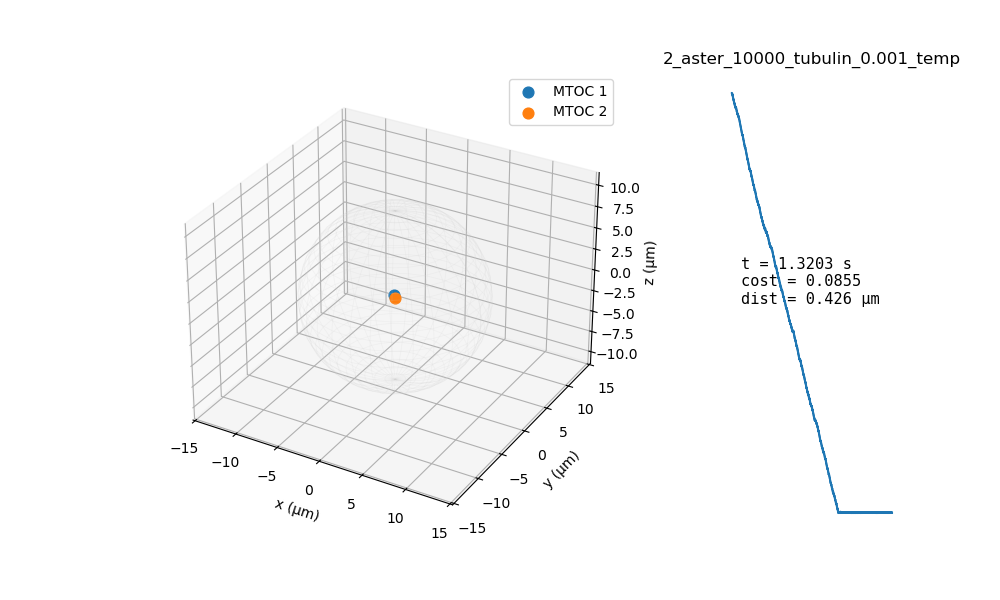

In [20]:
spindle.plot_cost()

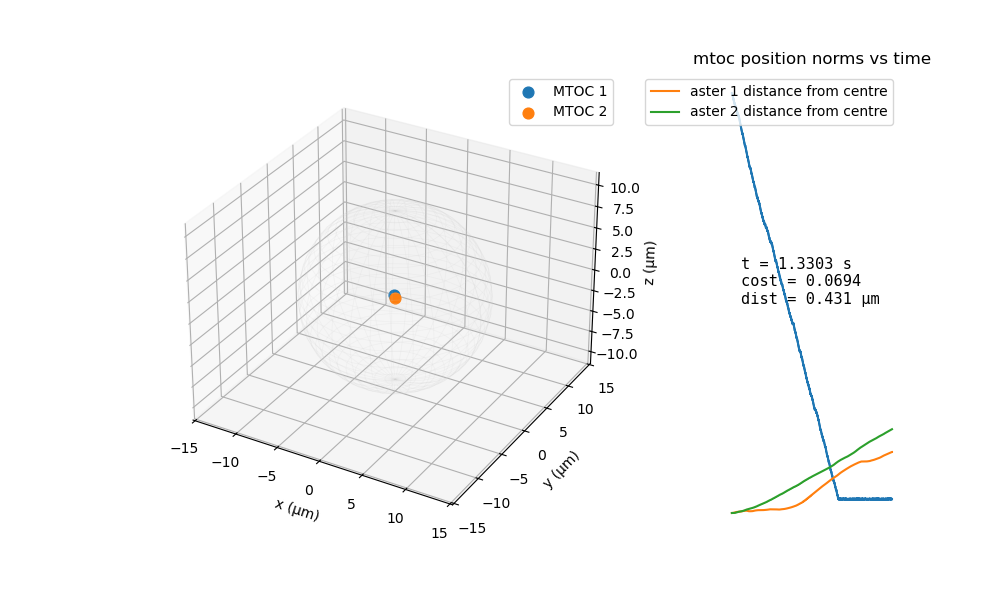

In [21]:
times = list(spindle.trajectory.keys())

norm1 = []
norm2 = []
aster_separations = []
for time in times:
    mtoc_positions = spindle.trajectory[time]['mtoc_pos']
    norm1.append(mas.normalize_vecs(mtoc_positions[1])[1])
    norm2.append(mas.normalize_vecs(mtoc_positions[2])[1])
    aster_separations.append(mas.normalize_vecs(mtoc_positions[1] - mtoc_positions[2])[1])


# plot aster position norms vs time 
plt.plot(times, norm1, label='aster 1 distance from centre')
plt.plot(times, norm2, label='aster 2 distance from centre')
plt.ylabel('Distance (um)')
plt.xlabel('time (s)')
plt.legend()
plt.title('mtoc position norms vs time')

aster_norm_plot_path = os.path.join(spindle.plot_folder_path, f'aster_norms.png')
plt.savefig(aster_norm_plot_path) 
plt.show()

In [22]:
# plot aster distance vs time 

plt.plot(times, aster_separations, label='distance between asters')
plt.ylabel('Distance (um)')
plt.xlabel('time (s)')
plt.title('mtoc separation vs time')

aster_sep_plot_path = os.path.join(spindle.plot_folder_path, f'aster_separation.png')
plt.savefig(aster_sep_plot_path)

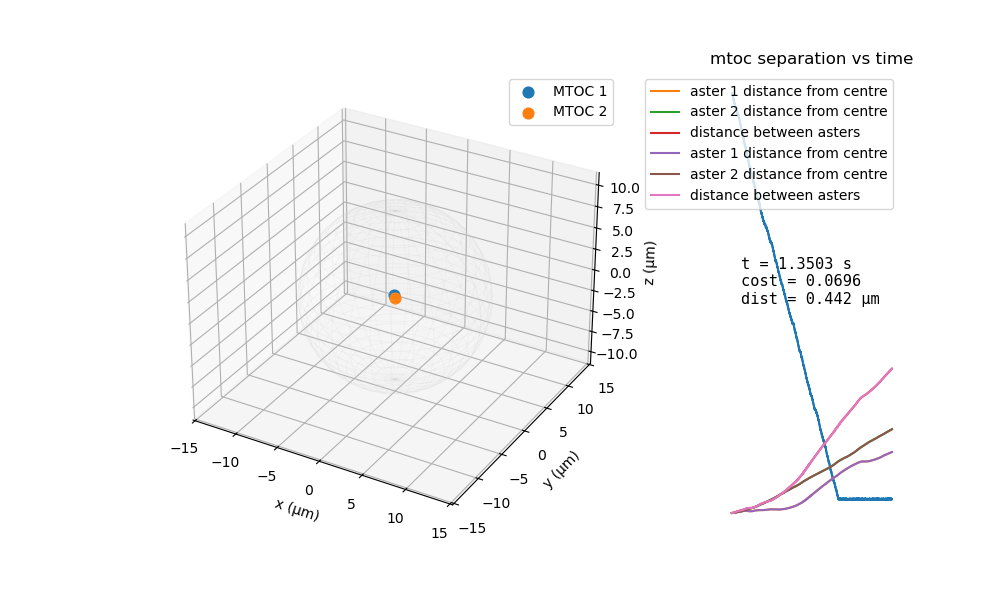

In [23]:
# plot aster position norms vs time 
plt.plot(times, norm1, label='aster 1 distance from centre')
plt.plot(times, norm2, label='aster 2 distance from centre')
plt.plot(times, aster_separations, label='distance between asters')
plt.ylabel('Distance (um)')
plt.xlabel('time (s)')
plt.legend()
# plt.title('mtoc position norms vs time')

# aster_norm_plot_path = os.path.join(spindle.plot_folder_path, f'aster_norms.png')
plt.savefig(aster_norm_plot_path) 
plt.show()

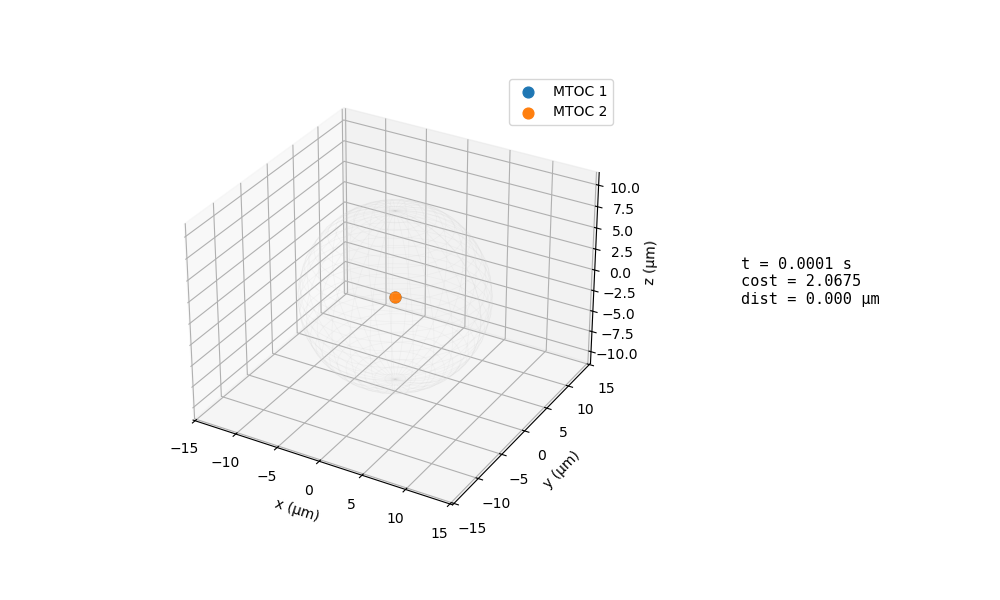

In [19]:
spindle.animate_mtoc_trajectory()